 Capillary Bridge Force Analysis Notebook

# 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import json
from pprint import pprint

cfg = json.load(open(r"Analysis_Files\config.json"))
image_dir = Path(cfg["image_dir"])
mask_dir  = Path(cfg["mask_dir"])
output_dir = Path(cfg["output_dir"])
lines_file = Path(cfg["lines_file"])
label_clf = Path(cfg["label_clf_path"])
side_clf  = Path(cfg["side_clf_path"])
excel_out = Path(cfg["output_dir"]) / cfg["excel_output"]
debug_dir = Path(cfg["output_dir"]) / cfg["debug_image_dir"]
first_frame_spacing = cfg["first_frame_spacing"]
sigma_surface_tension = cfg["sigma_surface_tension"]
pprint(cfg)

{'debug_image_dir': 'K:\\Capillary_bridging_data_alannah\\Silane Capillary '
                    'Action_07.30\\Trial2_100-400\\Output\\debug_images',
 'excel_output': 'Alannah_S1_training.xlsx',
 'first_frame_spacing': 0.0001,
 'image_dir': 'K:\\Capillary_bridging_data_alannah\\Silane Capillary '
              'Action_07.30\\Trial2_100-400',
 'label_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\mask_edge_classifier7.pkl',
 'lines_file': 'K:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action_07.30\\Trial2_100-400\\Output\\Alannah_S1_substrates.npz',
 'mask_dir': 'K:\\Capillary_bridging_data_alannah\\Silane Capillary '
             'Action_07.30\\Trial2_100-400\\masks_json',
 'output_dir': 'K:\\Capillary_bridging_data_alannah\\Silane Capillary '
               'Action_07.30\\Trial2_100-400\\Output',
 'side_clf_path': 'Analysis_Files\\Classifier_files\\trained_classifiers\\contour_side_classifier7.pkl',
 'sigma_surface_tension': 72}


In [2]:
#select new image folder path,and mask folder path, and output folder path
import tkinter as tk
from tkinter import filedialog
root = tk.Tk()
root.withdraw()  # Hide the root window
#keep the dialong on top
root.attributes('-topmost', True)

image_dir = Path(filedialog.askdirectory(title="Select Image Folder", initialdir=image_dir))
mask_dir = Path(filedialog.askdirectory(title="Select Mask Folder", initialdir=image_dir))
output_dir = Path(filedialog.askdirectory(title="Select Output Folder", initialdir=image_dir))
lines_file = output_dir / "Alannah_S1_substrates.npz"
debug_dir = output_dir / "debug_images"
#rewrite the config file with the new paths
cfg["image_dir"] = str(image_dir)
cfg["mask_dir"] = str(mask_dir)
cfg["output_dir"] = str(output_dir)
cfg["lines_file"] = str(lines_file)
cfg["debug_image_dir"] = str(debug_dir)
with open("Analysis_Files/config.json", "w") as f:
    json.dump(cfg, f, indent=4)
print(f"Image directory set to: {image_dir}")
print(f"Mask directory set to: {mask_dir}")
print(f"Output directory set to: {output_dir}")

Image directory set to: K:\Capillary_bridging_data_alannah\Silane Capillary Action_07.30\Trial4_100-550_Real
Mask directory set to: K:\Capillary_bridging_data_alannah\Silane Capillary Action_07.30\Trial4_100-550_Real\masks_json
Output directory set to: K:\Capillary_bridging_data_alannah\Silane Capillary Action_07.30\Trial4_100-550_Real\Output


# 2. Define Substrate Lines

In [15]:
%matplotlib qt
%run Analysis_Files\Substrate_tests\define_substrate_lines.py


KeyboardInterrupt: 

In [3]:
%matplotlib qt
%run Analysis_Files\Substrate_tests\view_substrate_lines.py

Found 81 images to process.


  0%|          | 0/81 [00:00<?, ?it/s]

Extracted features for 9 masks in frame_0000.png
[1 1 0 0 0 0 0 1 0]
Identified 3 edge masks in frame_0000.png


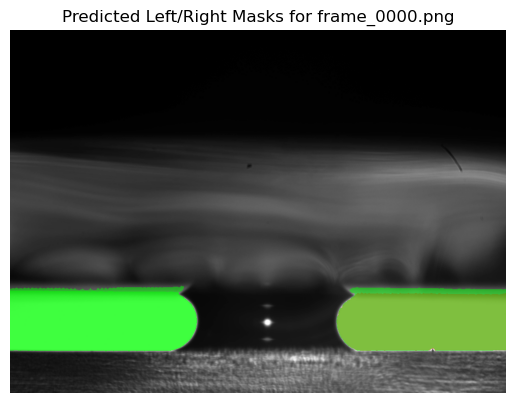

  1%|          | 1/81 [00:01<01:35,  1.19s/it]

Extracted features for 10 masks in frame_0015.png
[1 0 0 0 0 1 1 0 0 0]
Identified 3 edge masks in frame_0015.png


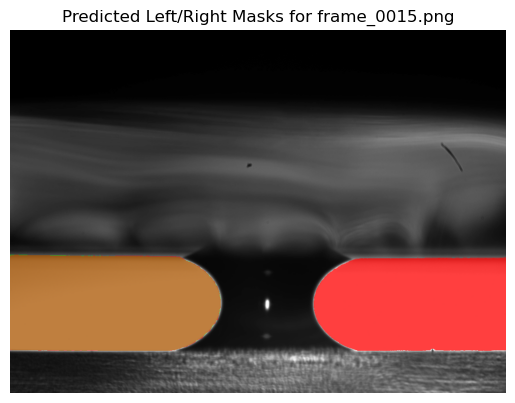

 20%|█▉        | 16/81 [00:02<00:09,  6.88it/s]

Extracted features for 11 masks in frame_0030.png
[1 1 0 0 0 0 0 1 0 0 0]
Identified 3 edge masks in frame_0030.png


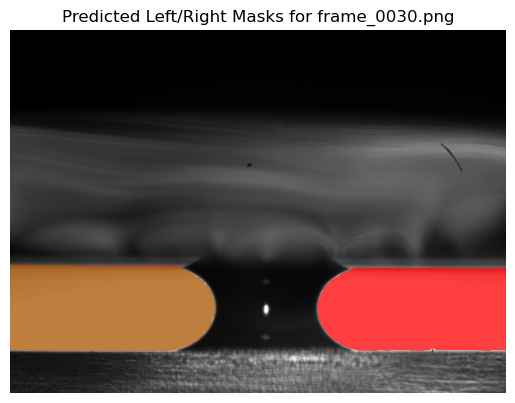

 38%|███▊      | 31/81 [00:04<00:06,  7.60it/s]

Extracted features for 11 masks in frame_0045.png
[1 1 1 0 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0045.png


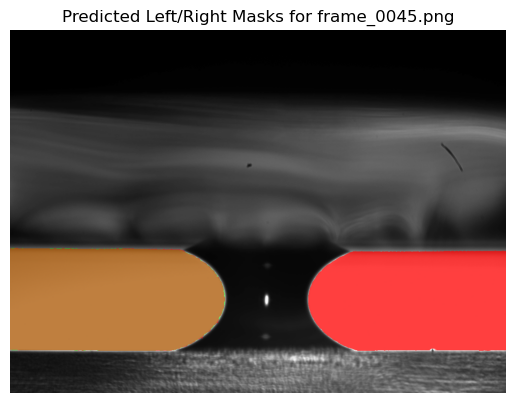

 57%|█████▋    | 46/81 [00:06<00:04,  7.86it/s]

Extracted features for 10 masks in frame_0060.png
[1 1 1 0 0 0 0 0 0 0]
Identified 3 edge masks in frame_0060.png


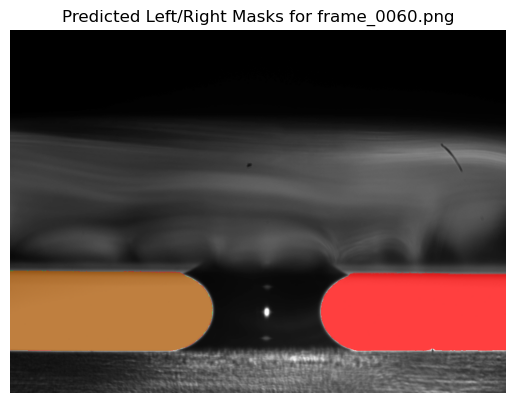

 75%|███████▌  | 61/81 [00:08<00:02,  8.02it/s]

Extracted features for 10 masks in frame_0075.png
[1 0 0 0 0 0 1 1 0 0]
Identified 3 edge masks in frame_0075.png


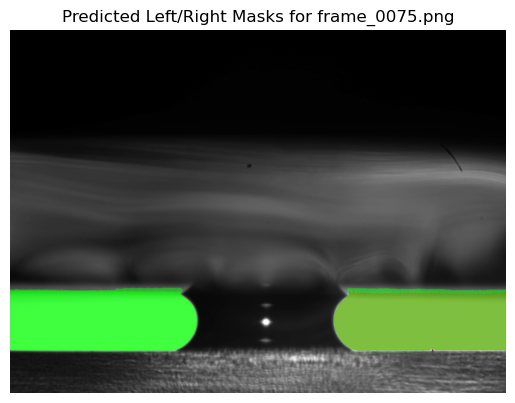

100%|██████████| 81/81 [00:09<00:00,  8.32it/s]


<Figure size 640x480 with 0 Axes>

In [4]:
%matplotlib inline
%run Analysis_Files/Classifier_files/Use_classifier.py

# 3. Run force analysis

In [5]:
%matplotlib inline
%run -i Analysis_Files\plot_forces_multiprocessing.py

Found 81 images in K:\Capillary_bridging_data_alannah\Silane Capillary Action_07.30\Trial4_100-550_Real


100%|██████████| 81/81 [00:50<00:00,  1.61it/s]



✅ Results saved to: K:\Capillary_bridging_data_alannah\Silane Capillary Action_07.30\Trial4_100-550_Real\Output\Alannah_S1_training.xlsx


# 4. Display Final Plot

C:\Users\Aj\Documents\GitHub\Capillary_Liquid_Bridges\Analysis_Files\Plot_from_excel.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_segments +1)


Plot saved to: K:\Capillary_bridging_data_alannah\Silane Capillary Action_07.30\trial1_dynamic\Output\capillary_bridge_forces_vs_plate_separation.png


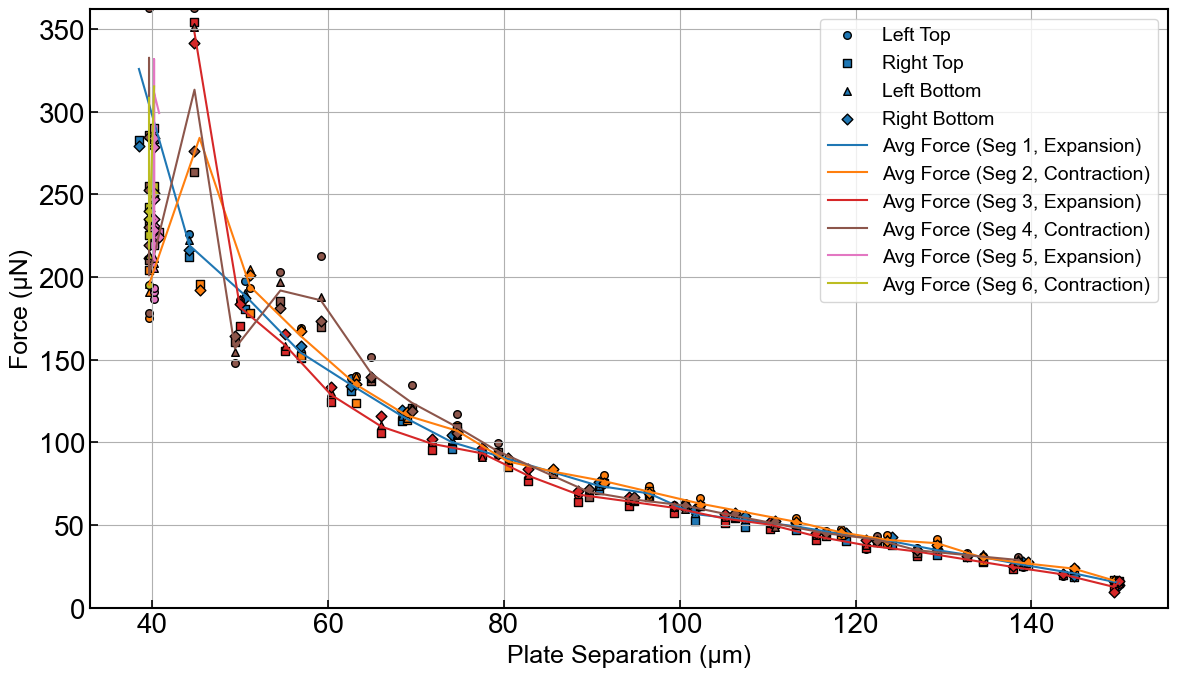

<Figure size 640x480 with 0 Axes>

In [7]:
%matplotlib inline
%run -i Analysis_Files/Plot_from_excel.py